In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/README.md
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/data.csv
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_52.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_10.tif
/kaggle/input/datasets/ma

# This code defines a PyTorch Dataset class for loading LGG MRI images and their corresponding masks.
# Key points:
# - Imports necessary libraries: os, numpy, PIL for image handling, torch for tensors.
# - The LGGDataset class:
#   - Initializes with the root directory of dataset and desired image size (default 256x256).
#   - Collects all image file paths (excluding mask files) from subdirectories.
#   - __len__ returns the total number of images.
#   - __getitem__:
#       - Loads the image and its corresponding mask.
#       - Converts both to grayscale ('L').
#       - Resizes images and masks to img_size x img_size.
#       - Normalizes image pixels to [0,1].
#       - Converts masks to binary (0 or 1).
#       - Adds a channel dimension to image and mask to make them compatible with PyTorch models.
#       - Returns a tuple of tensors: (image, mask).

In [ ]:
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=256):
        self.root_dir = root_dir
        self.img_size = img_size
        self.image_paths = []

    
        for patient in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient)
            if os.path.isdir(patient_path):
                for file in os.listdir(patient_path):
                    if file.endswith(".tif") and "_mask" not in file:
                        self.image_paths.append(os.path.join(patient_path, file))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = img_path.replace(".tif", "_mask.tif")

        # load image
        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        # resize
        image = image.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        # to numpy
        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.float32)

        # binary mask
        mask = (mask > 0).astype(np.float32)

        # add channel dim
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image), torch.tensor(mask)

# This code initializes a DataLoader for the LGGDataset.
# Key points:
# - Creates a dataset instance pointing to the root directory of the MRI dataset with image size 256x256.
# - Wraps the dataset in a DataLoader:
#     - batch_size=8
#     - shuffle=True to randomize data order each epoch
# - Quick test loop:
#     - Iterates over one batch of images and masks
#     - Prints the shape of images and masks to verify proper loading
#     - Expected output shape: [batch_size, channels, height, width] = [8, 1, 256, 256]

In [ ]:
from torch.utils.data import DataLoader

dataset = LGGDataset(root_dir="/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m", img_size=256)

loader = DataLoader(dataset, batch_size=8, shuffle=True)


for img, mask in loader:
    print(img.shape)   # [B, 1, 256, 256]
    print(mask.shape)  # [B, 1, 256, 256]
    break

torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])


# This cell sets the hyperparameters for training the segmentation model.
# Key parameters:
# - img_size: the input image size, here set to 128x128
# - batch_size: number of samples per batch during training, here 2
# - lr (learning rate): step size for optimizer updates, set to 0.001
# - epochs: total number of training iterations over the full dataset, set to 100

In [3]:
img_size = 128
batch_size = 2
lr = 1e-3
epochs = 100

# Split the dataset into training, validation, and test sets.
# - train_size: 70% of the dataset
# - val_size: 15% of the dataset
# - test_size: remaining 15%
# - random_split is used to randomly partition the dataset into these subsets

In [4]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

# Visualize the first image and its corresponding mask from the dataset using matplotlib.
# - img.squeeze() removes the channel dimension for display
# - mask.squeeze() similarly removes the channel dimension
# - Displays image on the left and mask on the right with titles

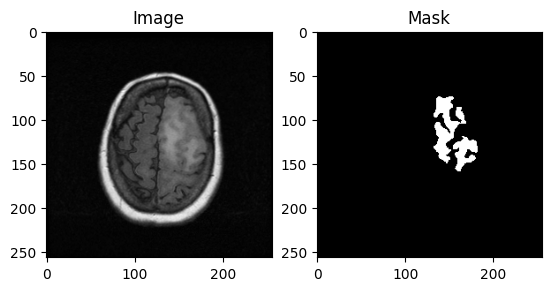

In [5]:
import matplotlib.pyplot as plt

img, mask = dataset[0]

plt.subplot(1,2,1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

# Define a small UNet model for image segmentation.
# - DoubleConv: helper block with two consecutive Conv2d + ReLU layers
# - UNetSmall:
#     - Encoder: three downsampling blocks with MaxPool
#     - Bridge: bottleneck between encoder and decoder
#     - Decoder: three upsampling blocks with ConvTranspose2d and skip connections
#     - Output: final 1-channel convolution for segmentation mask

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(32, 64)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(64, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv2 = DoubleConv(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.conv1 = DoubleConv(32, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        b = self.bridge(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.out(u1)

# Define custom loss functions for segmentation training:
# - DiceLoss: computes 1 minus the Dice coefficient for overlap between prediction and target
# - FocalBCEWithLogits: focal variant of BCE loss to handle class imbalance, with adjustable alpha and gamma
# - CombinedLoss: combines weighted BCE loss and DiceLoss equally for better optimization on imbalanced masks

In [8]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()
        dice = (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
        return 1 - dice


class FocalBCEWithLogits(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        pred_prob = torch.sigmoid(pred)

        focal = (1 - pred_prob) ** 2 * bce
        return focal.mean()
        

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]))

    def forward(self, pred, target):
        return 0.5 * self.bce(pred, target) + 0.5 * self.dice(pred, target)

# Define data augmentation transforms using torchvision:
# - RandomHorizontalFlip with 50% probability
# - RandomVerticalFlip with 50% probability
# - RandomRotation up to ±15 degrees

In [9]:
import torchvision.transforms as T

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(15)
])

# Compute the Dice score for predicted and target masks.
# - Applies sigmoid to predictions and thresholds them
# - Flattens tensors and computes overlap
# - Returns Dice coefficient as a measure of segmentation accuracy

In [10]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)

# Prepare the dataset and data loaders for training and validation:
# - Initialize LGGDataset with image size 128
# - Split dataset into train (70%), validation (15%), and test (15%) sets
# - Create DataLoaders with batch size 4; shuffle training data but not validation data

In [11]:
from torch.utils.data import DataLoader, random_split

# دیتاست
dataset = LGGDataset(root_dir="/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m", img_size=128)

# split
train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

# loaders
train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=4, shuffle=False)

# Function to train a segmentation model.
# - Moves model to specified device (CPU/GPU)
# - Uses Adam optimizer and CombinedLoss (Dice + weighted BCE)
# - Tracks training loss and validation Dice score per epoch
# - Saves model state if current validation Dice is the best so far
# - Prints epoch, training loss, and validation Dice score

In [12]:
def train_model(model, train_loader, val_loader, epochs=25, lr=1e-3, device="cpu"):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = CombinedLoss()

    best_dice = 0

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)

            optimizer.zero_grad()
            pred = model(img)
            loss = criterion(pred, mask)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ===== VALIDATION =====
        model.eval()
        dice_total = 0

        with torch.no_grad():
            for img, mask in val_loader:
                img, mask = img.to(device), mask.to(device)
                pred = model(img)
                dice_total += dice_score(pred, mask).item()

        val_dice = dice_total / len(val_loader)
        train_loss = train_loss / len(train_loader)

        print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Dice: {val_dice:.4f}")

        # save best
        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), "best_model.pth")

# Instantiate the UNetSmall model and train it using the previously defined train_model function
# - Uses training and validation loaders
# - Trains for 100 epochs with learning rate 0.001
# - Model checkpoints saved automatically based on best validation Dice score

In [14]:


model = UNetSmall()

train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    
)

Epoch 1 | Loss: 0.5395 | Dice: 0.1718
Epoch 2 | Loss: 0.4998 | Dice: 0.2361
Epoch 3 | Loss: 0.4760 | Dice: 0.2562
Epoch 4 | Loss: 0.4704 | Dice: 0.2589
Epoch 5 | Loss: 0.4648 | Dice: 0.2697
Epoch 6 | Loss: 0.4534 | Dice: 0.3174
Epoch 7 | Loss: 0.4414 | Dice: 0.3190
Epoch 8 | Loss: 0.4241 | Dice: 0.3632
Epoch 9 | Loss: 0.4024 | Dice: 0.4196
Epoch 10 | Loss: 0.3821 | Dice: 0.4724
Epoch 11 | Loss: 0.3517 | Dice: 0.4366
Epoch 12 | Loss: 0.3298 | Dice: 0.5319
Epoch 13 | Loss: 0.3305 | Dice: 0.5221
Epoch 14 | Loss: 0.2952 | Dice: 0.5763
Epoch 15 | Loss: 0.2819 | Dice: 0.5846
Epoch 16 | Loss: 0.2712 | Dice: 0.5762
Epoch 17 | Loss: 0.2680 | Dice: 0.6093
Epoch 18 | Loss: 0.2737 | Dice: 0.5822
Epoch 19 | Loss: 0.2461 | Dice: 0.6248
Epoch 20 | Loss: 0.2594 | Dice: 0.6168
Epoch 21 | Loss: 0.2318 | Dice: 0.6186
Epoch 22 | Loss: 0.2370 | Dice: 0.6060
Epoch 23 | Loss: 0.2352 | Dice: 0.6371
Epoch 24 | Loss: 0.2407 | Dice: 0.6300
Epoch 25 | Loss: 0.2241 | Dice: 0.6430
Epoch 26 | Loss: 0.2156 | Dice: 0.

# Define a PyTorch Dataset class for LGG MRI images.
# - Loads images and corresponding masks from subdirectories
# - Resizes images to img_size x img_size
# - Normalizes images to [0,1] and converts masks to binary
# - Adds a channel dimension to make tensors compatible with PyTorch models
# - Returns a tuple (image, mask) as torch tensors

In [13]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.root_dir = root_dir
        self.img_size = img_size
        self.samples = []

        for patient in os.listdir(root_dir):
            p_path = os.path.join(root_dir, patient)
            if os.path.isdir(p_path):
                for f in os.listdir(p_path):
                    if "_mask" not in f and f.endswith(".tif"):
                        self.samples.append(os.path.join(p_path, f))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        mask_path = img_path.replace(".tif", "_mask.tif")

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = np.array(img, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.float32)

        mask = (mask > 0).astype(np.float32)

        img = np.expand_dims(img, 0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)

# Define a standard UNet model for image segmentation.
# - DoubleConv: helper block with two consecutive Conv2d + ReLU layers
# - UNet architecture:
#     - Encoder: three downsampling blocks with MaxPool
#     - Bridge: bottleneck connecting encoder and decoder
#     - Decoder: three upsampling blocks using ConvTranspose2d and skip connections
#     - Output: final 1-channel convolution for predicted segmentation mask

In [7]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = DoubleConv(256, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = DoubleConv(128, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))

        b = self.bridge(self.p3(x3))

        y3 = self.u3(b)
        y3 = self.c3(torch.cat([y3, x3], 1))

        y2 = self.u2(y3)
        y2 = self.c2(torch.cat([y2, x2], 1))

        y1 = self.u1(y2)
        y1 = self.c1(torch.cat([y1, x1], 1))

        return self.out(y1)

In [14]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.view(-1)
        target = target.view(-1)

        inter = (pred * target).sum()
        dice = (2*inter + 1e-6) / (pred.sum() + target.sum() + 1e-6)
        return 1 - dice


class CombinedLoss(nn.Module):
    def __init__(self, device):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([5.0]).to(device)
        )
        self.dice = DiceLoss()

    def forward(self, pred, target):
        return 0.5*self.bce(pred, target) + 0.5*self.dice(pred, target)


def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    return (2*inter) / (pred.sum() + target.sum() + 1e-6)

# Train a segmentation model on the given dataset.
# - Moves model to GPU if available
# - Uses Adam optimizer and CombinedLoss (BCE + Dice)
# - Tracks training loss and validation Dice score per epoch
# - Saves model checkpoint when validation Dice improves

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, train_loader, val_loader, epochs=100, lr=1e-3):

    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CombinedLoss(device)

    best = 0

    for ep in range(epochs):

        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()

            train_loss += loss.item()

        model.eval()
        dice_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                dice_total += dice_score(pred, y).item()

        val_dice = dice_total / len(val_loader)

        print(f"Epoch {ep+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {val_dice:.4f}")

        if val_dice > best:
            best = val_dice
            torch.save(model.state_dict(), "best.pth")

# Prepare LGGDataset and DataLoaders for training and validation.
# - Split dataset into train (70%), validation (15%), and test (15%)
# - Create DataLoaders with batch size 2
# - Instantiate the UNet model and train it for 100 epochs using the train function

In [18]:
from torch.utils.data import DataLoader, random_split

dataset = LGGDataset("/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m", img_size=128)

train_size = int(0.7*len(dataset))
val_size = int(0.15*len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)
val_loader = DataLoader(val_set, batch_size=2)

model = UNet()

train(model, train_loader, val_loader, epochs=100)

Epoch 1 | Loss: 0.5376 | Dice: 0.1489
Epoch 2 | Loss: 0.5224 | Dice: 0.1600
Epoch 3 | Loss: 0.5121 | Dice: 0.1597
Epoch 4 | Loss: 0.5085 | Dice: 0.1641
Epoch 5 | Loss: 0.5026 | Dice: 0.1745
Epoch 6 | Loss: 0.5009 | Dice: 0.1835
Epoch 7 | Loss: 0.5021 | Dice: 0.1677
Epoch 8 | Loss: 0.4954 | Dice: 0.1908
Epoch 9 | Loss: 0.4921 | Dice: 0.2015
Epoch 10 | Loss: 0.4914 | Dice: 0.2048
Epoch 11 | Loss: 0.4866 | Dice: 0.1977
Epoch 12 | Loss: 0.4808 | Dice: 0.2296
Epoch 13 | Loss: 0.4821 | Dice: 0.2226
Epoch 14 | Loss: 0.4753 | Dice: 0.2313
Epoch 15 | Loss: 0.4757 | Dice: 0.2302
Epoch 16 | Loss: 0.4771 | Dice: 0.2319
Epoch 17 | Loss: 0.4723 | Dice: 0.2331
Epoch 18 | Loss: 0.4714 | Dice: 0.2317
Epoch 19 | Loss: 0.4683 | Dice: 0.2408
Epoch 20 | Loss: 0.4689 | Dice: 0.2347
Epoch 21 | Loss: 0.4671 | Dice: 0.2451
Epoch 22 | Loss: 0.4642 | Dice: 0.2452
Epoch 23 | Loss: 0.4622 | Dice: 0.2494
Epoch 24 | Loss: 0.4625 | Dice: 0.2418
Epoch 25 | Loss: 0.4614 | Dice: 0.2435
Epoch 26 | Loss: 0.4570 | Dice: 0.

# =========================
# Imports
# =========================
# Import necessary libraries for handling images, arrays, and PyTorch modules

# =========================
# Dataset
# =========================
# Define LGGDataset class:
# - Loads images and corresponding masks from subdirectories
# - Resizes images to img_size x img_size
# - Normalizes images and converts masks to binary
# - Adds a channel dimension and returns tensors (image, mask)

# =========================
# UNet
# =========================
# Define DoubleConv block: two consecutive Conv2d + ReLU layers
# Define UNet model:
# - Encoder: 3 downsampling blocks with MaxPool
# - Bridge: bottleneck connecting encoder and decoder
# - Decoder: 3 upsampling blocks with ConvTranspose2d and skip connections
# - Output: 1-channel segmentation mask

# =========================
# Loss Functions
# =========================
# DiceLoss: computes 1 - Dice coefficient for segmentation
# CombinedLoss: weighted combination of BCEWithLogitsLoss and DiceLoss for imbalanced data

# =========================
# Metric
# =========================
# dice_score function: computes Dice coefficient for evaluation
# - Applies sigmoid and threshold at 0.5
# - Calculates overlap between prediction and target

# =========================
# Train Function
# =========================
# train function:
# - Moves model to GPU if available
# - Uses Adam optimizer and CombinedLoss
# - Tracks training loss and validation Dice score per epoch
# - Saves model checkpoint when validation Dice improves

# =========================
# Data Loader
# =========================
# Initialize LGGDataset
# Split dataset into train (70%), validation (15%), and test (15%)
# Create DataLoaders with batch size 2

# =========================
# Run Training
# =========================
# Instantiate UNet model
# Train the model for 100 epochs using the train functio

In [25]:
import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split


# =========================
# Dataset
# =========================
class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.root_dir = root_dir
        self.img_size = img_size
        self.samples = []

        for patient in os.listdir(root_dir):
            p_path = os.path.join(root_dir, patient)
            if os.path.isdir(p_path):
                for f in os.listdir(p_path):
                    if "_mask" not in f and f.endswith(".tif"):
                        self.samples.append(os.path.join(p_path, f))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        mask_path = img_path.replace(".tif", "_mask.tif")

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = np.array(img, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.float32)

        mask = (mask > 0).astype(np.float32)

        img = np.expand_dims(img, 0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)


# =========================
# UNet
# =========================
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = DoubleConv(256, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = DoubleConv(128, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))

        b = self.bridge(self.p3(x3))

        y3 = self.u3(b)
        y3 = self.c3(torch.cat([y3, x3], 1))

        y2 = self.u2(y3)
        y2 = self.c2(torch.cat([y2, x2], 1))

        y1 = self.u1(y2)
        y1 = self.c1(torch.cat([y1, x1], 1))

        return self.out(y1)


# =========================
# Loss Functions
# =========================
class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.view(-1)
        target = target.view(-1)

        inter = (pred * target).sum()
        dice = (2 * inter + 1e-6) / (pred.sum() + target.sum() + 1e-6)
        return 1 - dice


class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.pos_weight = torch.tensor([5.0])
        self.dice = DiceLoss()

    def forward(self, pred, target):
        device = pred.device

        bce = nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weight.to(device)
        )

        return 0.5 * bce(pred, target) + 0.5 * self.dice(pred, target)


# =========================
# Metric
# =========================
def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    return (2 * inter) / (pred.sum() + target.sum() + 1e-6)


# =========================
# Train Function
# =========================
def train(model, train_loader, val_loader, epochs=50, lr=1e-3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CombinedLoss()

    best = 0

    for ep in range(epochs):

        # -------- train --------
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()

            train_loss += loss.item()

        # -------- validation --------
        model.eval()
        dice_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                dice_total += dice_score(pred, y).item()

        val_dice = dice_total / len(val_loader)

        print(f"Epoch {ep+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {val_dice:.4f}")

        if val_dice > best:
            best = val_dice
            torch.save(model.state_dict(), "best.pth")


# =========================
# Data Loader
# =========================
dataset = LGGDataset(
    "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m",
    img_size=128
)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)
val_loader = DataLoader(val_set, batch_size=2)


# =========================
# Run Training
# =========================
model = UNet()
train(model, train_loader, val_loader, epochs=100)

Epoch 1 | Loss: 0.5255 | Dice: 0.1546
Epoch 2 | Loss: 0.5114 | Dice: 0.1596
Epoch 3 | Loss: 0.5068 | Dice: 0.1623
Epoch 4 | Loss: 0.5052 | Dice: 0.1640
Epoch 5 | Loss: 0.5032 | Dice: 0.1735
Epoch 6 | Loss: 0.4990 | Dice: 0.1795
Epoch 7 | Loss: 0.4955 | Dice: 0.1919
Epoch 8 | Loss: 0.4901 | Dice: 0.1886
Epoch 9 | Loss: 0.4842 | Dice: 0.1870
Epoch 10 | Loss: 0.4819 | Dice: 0.2093
Epoch 11 | Loss: 0.4777 | Dice: 0.2118
Epoch 12 | Loss: 0.4775 | Dice: 0.2093
Epoch 13 | Loss: 0.4793 | Dice: 0.2194
Epoch 14 | Loss: 0.4732 | Dice: 0.2217
Epoch 15 | Loss: 0.4711 | Dice: 0.2111
Epoch 16 | Loss: 0.4717 | Dice: 0.2216
Epoch 17 | Loss: 0.4696 | Dice: 0.2280
Epoch 18 | Loss: 0.4694 | Dice: 0.2191
Epoch 19 | Loss: 0.4678 | Dice: 0.2245
Epoch 20 | Loss: 0.4673 | Dice: 0.2238
Epoch 21 | Loss: 0.4654 | Dice: 0.2185
Epoch 22 | Loss: 0.4645 | Dice: 0.2240
Epoch 23 | Loss: 0.4617 | Dice: 0.2266
Epoch 24 | Loss: 0.4617 | Dice: 0.2236
Epoch 25 | Loss: 0.4610 | Dice: 0.2313
Epoch 26 | Loss: 0.4585 | Dice: 0.

# Define an Attention Block for U-Net:
# - F_g: number of channels in the gating signal
# - F_l: number of channels in the skip connection feature
# - F_int: number of intermediate channels
# - Computes attention coefficients to weight the skip connection
# - forward(): applies 1x1 convolutions, batch normalization, ReLU, and sigmoid to generate attention map
# - Output: input feature x multiplied by attention map psi

In [7]:
import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU()

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

# Define an Attention U-Net model for image segmentation.
# - DoubleConv: two consecutive Conv2d + ReLU layers for feature extraction
# - Encoder: three downsampling blocks with MaxPool
# - Bridge: bottleneck connecting encoder and decoder
# - Decoder: three upsampling blocks using ConvTranspose2d
# - AttentionBlock: applies attention on skip connections to emphasize relevant features
# - Each decoder step concatenates upsampled features with attention-weighted encoder features
# - Output: 1-channel segmentation mask

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.att3 = AttentionBlock(128, 128, 64)
        self.c3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.att2 = AttentionBlock(64, 64, 32)
        self.c2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.att1 = AttentionBlock(32, 32, 16)
        self.c1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):

        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))

        b = self.bridge(self.p3(x3))

        u3 = self.up3(b)
        x3 = self.att3(u3, x3)
        u3 = self.c3(torch.cat([u3, x3], dim=1))

        u2 = self.up2(u3)
        x2 = self.att2(u2, x2)
        u2 = self.c2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(u2)
        x1 = self.att1(u1, x1)
        u1 = self.c1(torch.cat([u1, x1], dim=1))

        return self.out(u1)

# Define custom loss functions and evaluation metric for Attention U-Net:
# - DiceLoss: computes 1 minus Dice coefficient for predicted vs target masks
# - CombinedLoss: equally combines weighted BCEWithLogitsLoss (pos_weight=8) and DiceLoss
# - dice_score: computes Dice coefficient for evaluation by thresholding predictions at 0.5

In [9]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.view(-1)
        target = target.view(-1)

        inter = (pred * target).sum()
        return 1 - (2*inter + 1e-6) / (pred.sum() + target.sum() + 1e-6)


class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0]))
        self.dice = DiceLoss()

    def forward(self, pred, target):
        return 0.5*self.bce(pred, target) + 0.5*self.dice(pred, target)


def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    return (2*inter) / (pred.sum() + target.sum() + 1e-6)

# Train the Attention U-Net model.
# - Moves model to specified device (CPU/GPU)
# - Uses Adam optimizer and CombinedLoss (Dice + weighted BCE)
# - Tracks training loss and validation Dice score for each epoch
# - Saves model checkpoint when validation Dice improves

In [10]:
def train(model, train_loader, val_loader, epochs=100, lr=1e-3, device="cpu"):

    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CombinedLoss()

    best = 0

    for ep in range(epochs):

        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()

            train_loss += loss.item()

        model.eval()
        dice_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                dice_total += dice_score(pred, y).item()

        val_dice = dice_total / len(val_loader)

        print(f"Epoch {ep+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {val_dice:.4f}")

        if val_dice > best:
            best = val_dice
            torch.save(model.state_dict(), "best_attention_unet.pth")

# Function to train the Attention U-Net model.
# - Moves the model to the specified device (CPU or GPU)
# - Uses Adam optimizer and CombinedLoss (Dice + weighted BCE)
# - Tracks training loss and validation Dice score per epoch
# - Saves the model checkpoint when validation Dice improves

In [11]:
def train(model, train_loader, val_loader, epochs=100, lr=1e-3, device="cpu"):

    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CombinedLoss()

    best = 0

    for ep in range(epochs):

        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()

            train_loss += loss.item()

        model.eval()
        dice_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                dice_total += dice_score(pred, y).item()

        val_dice = dice_total / len(val_loader)

        print(f"Epoch {ep+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {val_dice:.4f}")

        if val_dice > best:
            best = val_dice
            torch.save(model.state_dict(), "best_attention_unet.pth")

# Prepare LGGDataset and DataLoaders for Attention U-Net training.
# - Split dataset into train (70%), validation (15%), and test (15%)
# - Create DataLoaders with batch size 2
# - Instantiate Attention U-Net model
# - Train the model for 100 epochs using the train function

In [ ]:
from torch.utils.data import DataLoader, random_split

dataset = LGGDataset("/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m", img_size=128)

train_size = int(0.7*len(dataset))
val_size = int(0.15*len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)
val_loader = DataLoader(val_set, batch_size=2)

model = AttentionUNet()

train(model, train_loader, val_loader, epochs=100)

Epoch 1 | Loss: 0.8332 | Dice: 0.1897
Epoch 2 | Loss: 0.5125 | Dice: 0.1875
Epoch 3 | Loss: 0.5069 | Dice: 0.1840
Epoch 4 | Loss: 0.4986 | Dice: 0.1814
Epoch 5 | Loss: 0.4970 | Dice: 0.1986
Epoch 6 | Loss: 0.4905 | Dice: 0.1739
Epoch 7 | Loss: 0.4829 | Dice: 0.2116
Epoch 8 | Loss: 0.4799 | Dice: 0.1954
Epoch 9 | Loss: 0.4724 | Dice: 0.1474
Epoch 10 | Loss: 0.4695 | Dice: 0.1805
Epoch 11 | Loss: 0.4706 | Dice: 0.2154
Epoch 12 | Loss: 0.4660 | Dice: 0.2119
Epoch 13 | Loss: 0.4592 | Dice: 0.2244
Epoch 14 | Loss: 0.4553 | Dice: 0.2104
Epoch 15 | Loss: 0.4530 | Dice: 0.1994
Epoch 16 | Loss: 0.4508 | Dice: 0.2292
Epoch 17 | Loss: 0.4479 | Dice: 0.2234
Epoch 18 | Loss: 0.4447 | Dice: 0.2526
Epoch 19 | Loss: 0.4457 | Dice: 0.2350
Epoch 20 | Loss: 0.4418 | Dice: 0.2383
Epoch 21 | Loss: 0.4348 | Dice: 0.2398
Epoch 22 | Loss: 0.4325 | Dice: 0.2530
Epoch 23 | Loss: 0.4345 | Dice: 0.2708
Epoch 24 | Loss: 0.4288 | Dice: 0.2618
Epoch 25 | Loss: 0.4286 | Dice: 0.2559
Epoch 26 | Loss: 0.4228 | Dice: 0.

# Import all necessary libraries:
# - os, numpy, PIL for file handling and image processing
# - torch, torch.nn, torch.nn.functional for building and training PyTorch models
# - Dataset, DataLoader for creating and batching datasets
# - matplotlib.pyplot for visualizing images and masks

In [3]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Define a PyTorch Dataset for LGG MRI images and masks:
# - Collects image-mask pairs from subdirectories
# - Resizes images and masks to img_size x img_size
# - Normalizes images to [0,1] and converts masks to binary
# - Adds a channel dimension for PyTorch compatibility
# - __getitem__ returns a tuple of tensors: (image, mask)

In [6]:
class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.samples = []
        self.img_size = img_size

        for patient in os.listdir(root_dir):
            p_path = os.path.join(root_dir, patient)

            if not os.path.isdir(p_path):
                continue

            for f in os.listdir(p_path):
                if f.endswith(".tif") and "_mask" not in f:
                    img_path = os.path.join(p_path, f)
                    mask_path = img_path.replace(".tif", "_mask.tif")

                    if os.path.exists(mask_path):
                        self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = np.array(img, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        mask = (mask > 0).astype(np.float32)

        img = np.expand_dims(img, 0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)

# Define an Attention U-Net variant for segmentation:
# - ConvBlock: two Conv2d + ReLU layers for feature extraction
# - AttentionBlock: computes attention map to weight skip connections
# - Encoder: two ConvBlocks with MaxPool
# - Bottleneck: ConvBlock at the bridge
# - Decoder: single upsampling with attention applied to encoder features
# - Output: 1-channel mask, interpolated to match input size
# - Note: Only one upsampling layer is used here; a second upsampling may be required for full U-Net

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class AttentionBlock(nn.Module):
    def __init__(self, g, x, inter):
        super().__init__()
        self.Wg = nn.Conv2d(g, inter, 1)
        self.Wx = nn.Conv2d(x, inter, 1)
        self.psi = nn.Conv2d(inter, 1, 1)

    def forward(self, g, x):
        att = torch.relu(self.Wg(g) + self.Wx(x))
        att = torch.sigmoid(self.psi(att))
        return x * att


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up = nn.ConvTranspose2d(256, 128, 2, 2)
        self.att = AttentionBlock(128, 128, 64)
        self.dec = ConvBlock(256, 128)

        self.out = nn.Conv2d(128, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
    
        b = self.bottleneck(self.pool(e2))
    
        # decoder 1
        u1 = self.up(b)
        e2_att = self.att(u1, e2)
        d1 = torch.cat([u1, e2_att], dim=1)
        d1 = self.dec(d1)
    
        # اگر فقط 1 upsample داری → خروجی 64 میشه (اشتباه)
        # باید اینجا upsample دوم اضافه بشه
    
        out = self.out(d1)
        return F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)

# Define a custom loss function combining BCE and Focal Tversky Loss:
# - BCEWithLogitsLoss handles pixel-wise binary classification
# - Tversky index balances false positives (alpha) and false negatives (beta)
# - Focal term emphasizes hard-to-segment pixels (gamma)
# - Forward returns weighted sum: 0.5 * BCE + 0.5 * Focal Tversky

In [8]:
class LossFn(nn.Module):
    def __init__(self, a=0.7, b=0.3, g=0.75):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.a = a
        self.b = b
        self.g = g

    def forward(self, pred, true):
        bce = self.bce(pred, true)
        pred = torch.sigmoid(pred)

        tp = (pred * true).sum()
        fp = ((1 - true) * pred).sum()
        fn = (true * (1 - pred)).sum()

        tversky = (tp + 1e-6) / (tp + self.a*fp + self.b*fn + 1e-6)
        focal = (1 - tversky) ** self.g

        return 0.5 * bce + 0.5 * focal

# Initialize the LGGDataset and DataLoader:
# - root: path to the dataset
# - img_size: resize images to 128×128
# - batch_size: 8
# - shuffle: True to randomize data order each epoch

In [9]:
root = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

dataset = LGGDataset(root, img_size=128)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

# Train the Attention U-Net model using the custom LossFn:
# - Moves model and data to GPU if available
# - Uses Adam optimizer with learning rate 1e-4
# - Loops over specified number of epochs (25)
# - Computes loss, backpropagates, and updates model parameters
# - Prints average training loss per epoch

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)
loss_fn = LossFn()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/25 | Loss: 0.4942
Epoch 2/25 | Loss: 0.4474
Epoch 3/25 | Loss: 0.4249
Epoch 4/25 | Loss: 0.3982
Epoch 5/25 | Loss: 0.3645
Epoch 6/25 | Loss: 0.3425
Epoch 7/25 | Loss: 0.3273
Epoch 8/25 | Loss: 0.3227
Epoch 9/25 | Loss: 0.3175
Epoch 10/25 | Loss: 0.3092
Epoch 11/25 | Loss: 0.3048
Epoch 12/25 | Loss: 0.2975
Epoch 13/25 | Loss: 0.2866
Epoch 14/25 | Loss: 0.2841
Epoch 15/25 | Loss: 0.2836
Epoch 16/25 | Loss: 0.2745
Epoch 17/25 | Loss: 0.2727
Epoch 18/25 | Loss: 0.2581
Epoch 19/25 | Loss: 0.2576
Epoch 20/25 | Loss: 0.2483
Epoch 21/25 | Loss: 0.2456
Epoch 22/25 | Loss: 0.2429
Epoch 23/25 | Loss: 0.2365
Epoch 24/25 | Loss: 0.2335
Epoch 25/25 | Loss: 0.2374


# Visualize model predictions on sample images from the dataset:
# - model.eval() ensures evaluation mode
# - Uses torch.sigmoid to convert outputs to probabilities
# - Displays n samples (default 3)
# - Plots side-by-side:
#     1. Original MRI image
#     2. Ground truth mask
#     3. Predicted mask by the model
# - Uses matplotlib for visualization

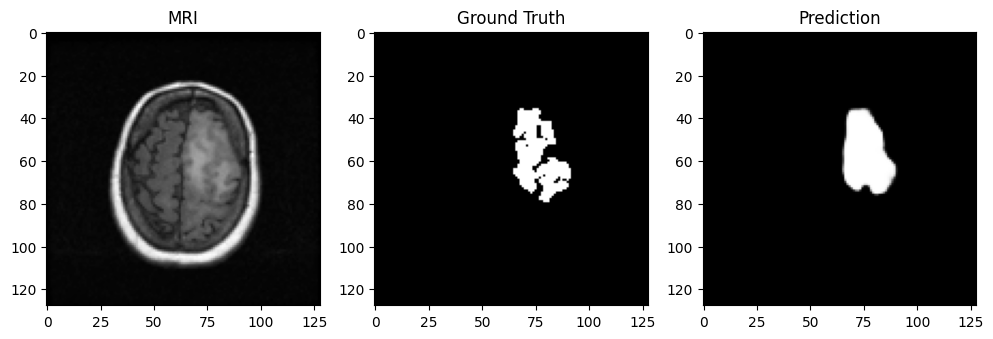

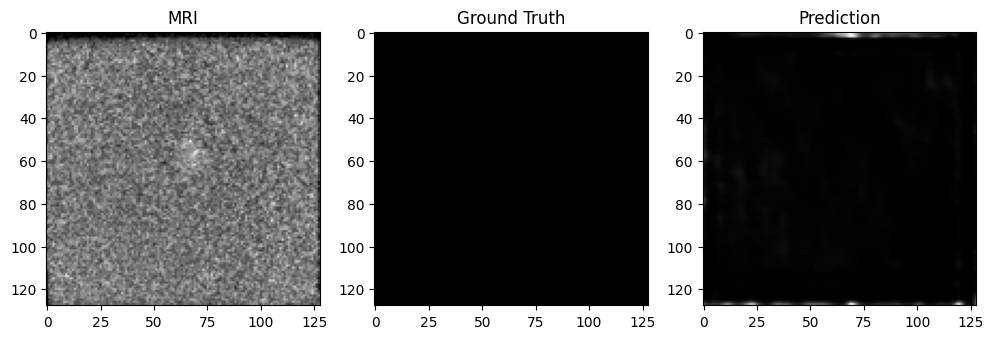

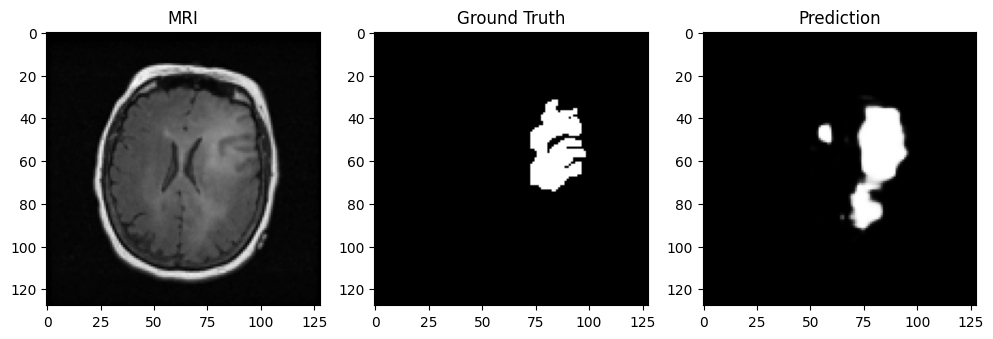

In [13]:
def visualize(model, dataset, n=3):
    model.eval()

    for i in range(n):
        img, mask = dataset[i]
        img_in = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(img_in)).cpu().squeeze().numpy()

        img = img.squeeze().numpy()
        mask = mask.squeeze().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("MRI")
        plt.imshow(img, cmap='gray')

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap='gray')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap='gray')

        plt.show()

visualize(model, dataset)

# Import essential libraries:
# - os, numpy, PIL for file and image handling
# - torch, torch.nn, torch.nn.functional for model building and training
# - Dataset, DataLoader for dataset management and batching
# - matplotlib.pyplot for visualizing images and masks

In [14]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Define a PyTorch Dataset for LGG MRI images and their masks:
# - Collects image-mask pairs from subdirectories of root_dir
# - Resizes images and masks to img_size x img_size
# - Normalizes image pixels to [0,1] and converts masks to binary
# - Adds a channel dimension for PyTorch model compatibility
# - __getitem__ returns a tuple of tensors: (image, mask)

In [15]:
class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.samples = []
        self.img_size = img_size

        for patient in os.listdir(root_dir):
            p_path = os.path.join(root_dir, patient)

            if not os.path.isdir(p_path):
                continue

            for f in os.listdir(p_path):
                if f.endswith(".tif") and "_mask" not in f:
                    img_path = os.path.join(p_path, f)
                    mask_path = img_path.replace(".tif", "_mask.tif")

                    if os.path.exists(mask_path):
                        self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = np.array(img, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        mask = (mask > 0).astype(np.float32)

        img = np.expand_dims(img, 0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)

# Define an Attention U-Net model for segmentation:
# - ConvBlock: two Conv2d + ReLU layers for feature extraction
# - AttentionBlock: computes attention maps to weight skip connections
# - Encoder: two ConvBlocks with MaxPool for downsampling
# - Bottleneck: ConvBlock at the bridge
# - Decoder: two upsampling layers with attention applied to skip connections
# - Output: 1-channel segmentation mask
# - forward(): concatenates upsampled features with attention-weighted encoder features

In [16]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class AttentionBlock(nn.Module):
    def __init__(self, g, x, inter):
        super().__init__()
        self.Wg = nn.Conv2d(g, inter, 1)
        self.Wx = nn.Conv2d(x, inter, 1)
        self.psi = nn.Conv2d(inter, 1, 1)

    def forward(self, g, x):
        att = torch.relu(self.Wg(g) + self.Wx(x))
        att = torch.sigmoid(self.psi(att))
        return x * att


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)

        # Decoder 1
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.att1 = AttentionBlock(128, 128, 64)
        self.dec1 = ConvBlock(256, 128)

        # Decoder 2
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ConvBlock(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        u1 = self.up1(b)
        e2 = self.att1(u1, e2)
        d1 = torch.cat([u1, e2], dim=1)
        d1 = self.dec1(d1)

        u2 = self.up2(d1)
        d2 = torch.cat([u2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.out(d2)

# Define an Attention U-Net model for image segmentation:
# - ConvBlock: two Conv2d + ReLU layers for feature extraction
# - AttentionBlock: applies attention to encoder features before concatenation
# - Encoder: two ConvBlocks with MaxPool for downsampling
# - Bottleneck: ConvBlock connecting encoder and decoder
# - Decoder: two upsampling layers, first uses attention on skip connection
# - Output: 1-channel segmentation mask
# - forward(): performs encoding, bottleneck, decoding with skip connections and attention

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class AttentionBlock(nn.Module):
    def __init__(self, g, x, inter):
        super().__init__()
        self.Wg = nn.Conv2d(g, inter, 1)
        self.Wx = nn.Conv2d(x, inter, 1)
        self.psi = nn.Conv2d(inter, 1, 1)

    def forward(self, g, x):
        att = torch.relu(self.Wg(g) + self.Wx(x))
        att = torch.sigmoid(self.psi(att))
        return x * att


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)

        # Decoder 1
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.att1 = AttentionBlock(128, 128, 64)
        self.dec1 = ConvBlock(256, 128)

        # Decoder 2
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ConvBlock(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        u1 = self.up1(b)
        e2 = self.att1(u1, e2)
        d1 = torch.cat([u1, e2], dim=1)
        d1 = self.dec1(d1)

        u2 = self.up2(d1)
        d2 = torch.cat([u2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.out(d2)

# Define a custom loss function combining BCE and Focal Tversky Loss:
# - BCEWithLogitsLoss handles pixel-wise binary classification
# - Tversky index balances false positives (alpha) and false negatives (beta)
# - Focal term (gamma) emphasizes hard-to-segment pixels
# - forward() returns weighted sum: 0.5 * BCE + 0.5 * Focal Tversky

In [18]:
class LossFn(nn.Module):
    def __init__(self, a=0.7, b=0.3, g=0.75):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.a = a
        self.b = b
        self.g = g

    def forward(self, pred, true):
        bce = self.bce(pred, true)
        pred = torch.sigmoid(pred)

        tp = (pred * true).sum()
        fp = ((1 - true) * pred).sum()
        fn = (true * (1 - pred)).sum()

        tversky = (tp + 1e-6) / (tp + self.a*fp + self.b*fn + 1e-6)
        focal = (1 - tversky) ** self.g

        return 0.5 * bce + 0.5 * focal

# Compute the Dice coefficient for predicted and target masks:
# - Applies sigmoid and thresholds predictions at 0.5
# - Computes intersection and union per image
# - Returns mean Dice score across the batch

In [19]:
def dice_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = (2. * intersection + smooth) / (union + smooth)

    return dice.mean()

# Initialize the LGGDataset and DataLoader:
# - root: dataset directory
# - img_size: resize images to 128×128
# - batch_size: 8
# - shuffle: True to randomize data order each epoch

In [20]:
root = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

dataset = LGGDataset(root, img_size=128)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

# Train the Attention U-Net model:
# - Moves model and data to GPU if available
# - Uses Adam optimizer with learning rate 1e-4
# - Computes loss using custom LossFn (BCE + Focal Tversky)
# - Tracks both training loss and Dice score per epoch
# - Prints average loss and Dice over the training set for each epoch

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)
loss_fn = LossFn()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 25

for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_dice = 0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(pred, mask).item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss/len(train_loader):.4f} | "
        f"Dice: {total_dice/len(train_loader):.4f}"
    )

Epoch 1/25 | Loss: 0.5104 | Dice: 0.6032
Epoch 2/25 | Loss: 0.4517 | Dice: 0.5718
Epoch 3/25 | Loss: 0.4238 | Dice: 0.5968
Epoch 4/25 | Loss: 0.3976 | Dice: 0.6145
Epoch 5/25 | Loss: 0.3584 | Dice: 0.6339
Epoch 6/25 | Loss: 0.3399 | Dice: 0.6656
Epoch 7/25 | Loss: 0.3166 | Dice: 0.6994
Epoch 8/25 | Loss: 0.3206 | Dice: 0.7032
Epoch 9/25 | Loss: 0.3030 | Dice: 0.7031
Epoch 10/25 | Loss: 0.2933 | Dice: 0.7168
Epoch 11/25 | Loss: 0.2792 | Dice: 0.7260
Epoch 12/25 | Loss: 0.2812 | Dice: 0.7244
Epoch 13/25 | Loss: 0.2647 | Dice: 0.7535
Epoch 14/25 | Loss: 0.2689 | Dice: 0.7404
Epoch 15/25 | Loss: 0.2626 | Dice: 0.7675
Epoch 16/25 | Loss: 0.2458 | Dice: 0.7697
Epoch 17/25 | Loss: 0.2437 | Dice: 0.7642
Epoch 18/25 | Loss: 0.2343 | Dice: 0.7830
Epoch 19/25 | Loss: 0.2260 | Dice: 0.7883
Epoch 20/25 | Loss: 0.2246 | Dice: 0.7984
Epoch 21/25 | Loss: 0.2207 | Dice: 0.7981
Epoch 22/25 | Loss: 0.2250 | Dice: 0.7930
Epoch 23/25 | Loss: 0.2001 | Dice: 0.8072
Epoch 24/25 | Loss: 0.2190 | Dice: 0.8034
E

# Visualize predictions of the trained model on sample images:
# - model.eval() ensures evaluation mode
# - Uses torch.sigmoid to convert model outputs to probabilities
# - Loops over n samples from the dataset (default 3)
# - Plots side-by-side:
#     1. Original MRI image
#     2. Ground truth mask
#     3. Model prediction mask
# - Uses matplotlib for visualization

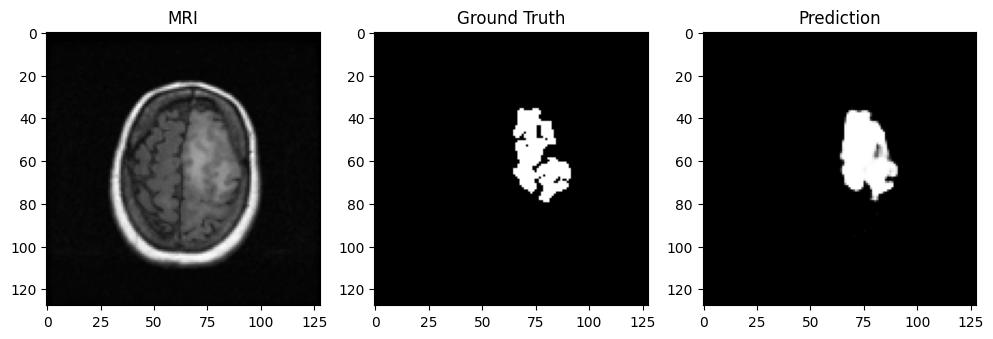

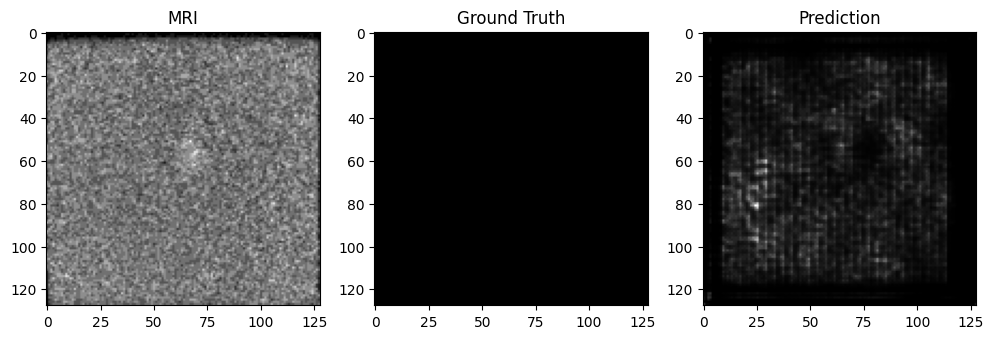

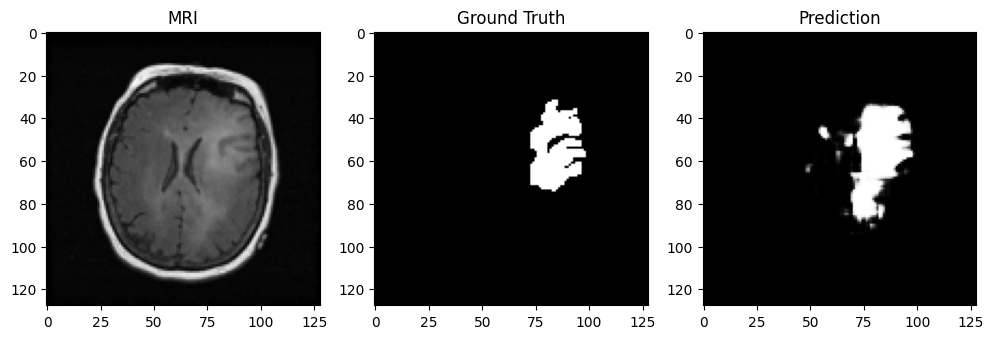

In [23]:
def visualize(model, dataset, n=3):
    model.eval()

    for i in range(n):
        img, mask = dataset[i]
        img_in = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(img_in)).cpu().squeeze().numpy()

        img = img.squeeze().numpy()
        mask = mask.squeeze().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("MRI")
        plt.imshow(img, cmap='gray')

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap='gray')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap='gray')

        plt.show()

visualize(model, dataset)

# Import essential libraries for dataset handling, model building, and visualization:
# - os, numpy, PIL for file and image operations
# - torch, torch.nn, torch.nn.functional for defining and training neural networks
# - Dataset, DataLoader, random_split for managing datasets and batching
# - matplotlib.pyplot for plotting images and masks
# - random for any random operations or reproducibility

In [24]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import random

# Define a PyTorch Dataset class for LGG MRI images and masks:
# - Collects valid image-mask pairs from subdirectories of root_dir
# - Resizes images and masks to img_size x img_size
# - Normalizes image pixels to [0,1] and converts masks to binary
# - Adds a channel dimension to both image and mask tensors
# - __getitem__ returns a tuple: (image_tensor, mask_tensor)

In [25]:
class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.samples = []
        self.img_size = img_size

        for patient in os.listdir(root_dir):
            p_path = os.path.join(root_dir, patient)

            if not os.path.isdir(p_path):
                continue

            for f in os.listdir(p_path):
                if f.endswith(".tif") and "_mask" not in f:
                    img_path = os.path.join(p_path, f)
                    mask_path = img_path.replace(".tif", "_mask.tif")

                    if os.path.exists(mask_path):
                        self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = np.array(img, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        mask = (mask > 0).astype(np.float32)

        img = np.expand_dims(img, 0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)

# Define an Attention U-Net model for segmentation:
# - ConvBlock: two Conv2d + ReLU layers for feature extraction
# - AttentionBlock: computes attention map to weight encoder features before concatenation
# - Encoder: two ConvBlocks with MaxPool downsampling
# - Bottleneck: ConvBlock bridging encoder and decoder
# - Decoder: two upsampling layers, first uses attention on skip connection
# - Output: 1-channel segmentation mask
# - forward(): passes input through encoder, bottleneck, decoder with skip connections and attention

In [26]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class AttentionBlock(nn.Module):
    def __init__(self, g, x, inter):
        super().__init__()
        self.Wg = nn.Conv2d(g, inter, 1)
        self.Wx = nn.Conv2d(x, inter, 1)
        self.psi = nn.Conv2d(inter, 1, 1)

    def forward(self, g, x):
        att = torch.relu(self.Wg(g) + self.Wx(x))
        att = torch.sigmoid(self.psi(att))
        return x * att


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.att1 = AttentionBlock(128, 128, 64)
        self.dec1 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ConvBlock(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        u1 = self.up1(b)
        e2 = self.att1(u1, e2)
        d1 = torch.cat([u1, e2], dim=1)
        d1 = self.dec1(d1)

        u2 = self.up2(d1)
        d2 = torch.cat([u2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.out(d2)

# Define a custom loss function combining BCE and Focal Tversky:
# - BCEWithLogitsLoss handles pixel-wise binary classification
# - Tversky index balances false positives (alpha) and false negatives (beta)
# - Focal term (gamma) emphasizes hard-to-segment pixels
# - forward() returns weighted sum: 0.5 * BCE + 0.5 * Focal Tversky

In [27]:
class LossFn(nn.Module):
    def __init__(self, a=0.7, b=0.3, g=0.75):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.a = a
        self.b = b
        self.g = g

    def forward(self, pred, true):
        bce = self.bce(pred, true)
        pred = torch.sigmoid(pred)

        tp = (pred * true).sum()
        fp = ((1 - true) * pred).sum()
        fn = (true * (1 - pred)).sum()

        tversky = (tp + 1e-6) / (tp + self.a*fp + self.b*fn + 1e-6)
        focal = (1 - tversky) ** self.g

        return 0.5 * bce + 0.5 * focal

# Define evaluation metrics for segmentation:
# - dice_score: computes Dice coefficient for predicted vs target masks
# - iou_score: computes Intersection over Union (IoU) for predicted vs target masks
# - Both apply sigmoid and threshold predictions at 0.5 before calculation

In [28]:
def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    return (2 * inter + 1e-6) / (pred.sum() + target.sum() + 1e-6)


def iou_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter

    return (inter + 1e-6) / (union + 1e-6)

# Prepare LGGDataset and DataLoaders:
# - root: path to dataset
# - img_size: resize images to 128×128
# - Split dataset into training (80%) and validation (20%)
# - Create DataLoaders with batch size 8; shuffle training data but not validation

In [30]:
root = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

dataset = LGGDataset(root, img_size=128)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

# Train and validate the Attention U-Net model:
# - Moves model and data to GPU if available
# - Uses Adam optimizer with learning rate 1e-4 and custom LossFn (BCE + Focal Tversky)
# - Tracks training loss and Dice score for each batch
# - Evaluates validation Dice and IoU after each epoch
# - Prints average training loss, training Dice, validation Dice, and validation IoU per epoch

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)
loss_fn = LossFn()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 15

for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    train_loss, train_dice = 0, 0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(pred, mask).item()

    # -------- VAL --------
    model.eval()
    val_dice, val_iou = 0, 0

    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)

            pred = model(img)

            val_dice += dice_score(pred, mask).item()
            val_iou += iou_score(pred, mask).item()

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Dice: {train_dice/len(train_loader):.4f} | "
        f"Val Dice: {val_dice/len(val_loader):.4f} | "
        f"Val IoU: {val_iou/len(val_loader):.4f}"
    )

Epoch 1 | Loss: 0.5115 | Train Dice: 0.0535 | Val Dice: 0.0625 | Val IoU: 0.0569
Epoch 2 | Loss: 0.4583 | Train Dice: 0.2249 | Val Dice: 0.2640 | Val IoU: 0.1723
Epoch 3 | Loss: 0.4401 | Train Dice: 0.2523 | Val Dice: 0.2817 | Val IoU: 0.1927
Epoch 4 | Loss: 0.4189 | Train Dice: 0.2872 | Val Dice: 0.3302 | Val IoU: 0.2266
Epoch 5 | Loss: 0.3997 | Train Dice: 0.3235 | Val Dice: 0.4046 | Val IoU: 0.2819
Epoch 6 | Loss: 0.3731 | Train Dice: 0.3768 | Val Dice: 0.3290 | Val IoU: 0.2292
Epoch 7 | Loss: 0.3515 | Train Dice: 0.4111 | Val Dice: 0.4189 | Val IoU: 0.2974
Epoch 8 | Loss: 0.3299 | Train Dice: 0.4521 | Val Dice: 0.4763 | Val IoU: 0.3412
Epoch 9 | Loss: 0.3196 | Train Dice: 0.4710 | Val Dice: 0.4842 | Val IoU: 0.3515
Epoch 10 | Loss: 0.3128 | Train Dice: 0.4862 | Val Dice: 0.4977 | Val IoU: 0.3633
Epoch 11 | Loss: 0.3056 | Train Dice: 0.5030 | Val Dice: 0.5088 | Val IoU: 0.3742
Epoch 12 | Loss: 0.3028 | Train Dice: 0.5153 | Val Dice: 0.5054 | Val IoU: 0.3682
Epoch 13 | Loss: 0.2920 |

# Implement a simple hyperparameter optimization using Differential Evolution (DE) for learning rate:
# - evaluate(): trains the given model for a few batches and returns negative total loss (for maximization)
# - DE():
#     - Initializes a population of candidate learning rates (log-uniform sampling)
#     - Iteratively evolves the population over several iterations
#     - Uses mutation and recombination to propose new candidates
#     - Selects and prints the best learning rate per iteration
# - Returns the best learning rate found after all iterations

In [43]:
def evaluate(lr, model_class):
    model = model_class().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = LossFn()

    model.train()
    loss_sum = 0

    for i, (img, mask) in enumerate(train_loader):
        if i > 3: break

        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_sum += loss.item()

    return -loss_sum


def DE(iterations=3, pop_size=5):
    pop = [10**np.random.uniform(-5, -3) for _ in range(pop_size)]

    for _ in range(iterations):
        scores = [evaluate(lr, AttentionUNet) for lr in pop]

        best_idx = np.argmax(scores)
        best = pop[best_idx]

        new_pop = []

        for i in range(pop_size):
            a, b, c = random.sample(pop, 3)

            mutant = a + 0.8 * (b - c)
            mutant = max(1e-6, min(mutant, 1e-2))

            new_pop.append(mutant)

        pop = new_pop

        print("Best LR:", best)

    return best

# Run the Differential Evolution (DE) optimization to find the best learning rate:
# - Calls DE() function to search for optimal learning rate
# - Prints the final best learning rate after all iterations

In [44]:
best_lr = DE()
print("FINAL BEST LR:", best_lr)

Best LR: 0.0008159688202066135
Best LR: 0.001283132896309091
Best LR: 0.0011211291162401213
FINAL BEST LR: 0.0011211291162401213


# Visualize model predictions on sample images:
# - model.eval() sets the model to evaluation mode
# - Applies sigmoid to model outputs to convert to probabilities
# - Loops over n samples from the dataset (default 3)
# - Plots side-by-side:
#     1. Original MRI image
#     2. Ground truth mask
#     3. Model prediction mask
# - Uses matplotlib for visualization

In [46]:
def visualize(model, dataset, n=3):
    model.eval()

    for i in range(n):
        img, mask = dataset[i]
        img_in = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(img_in)).cpu().squeeze().numpy()

        img = img.squeeze().numpy()
        mask = mask.squeeze().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("MRI")
        plt.imshow(img, cmap='gray')

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap='gray')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap='gray')

        plt.show()

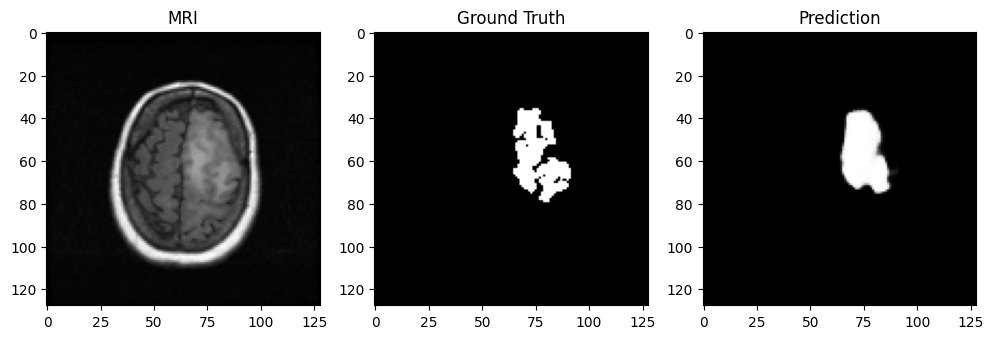

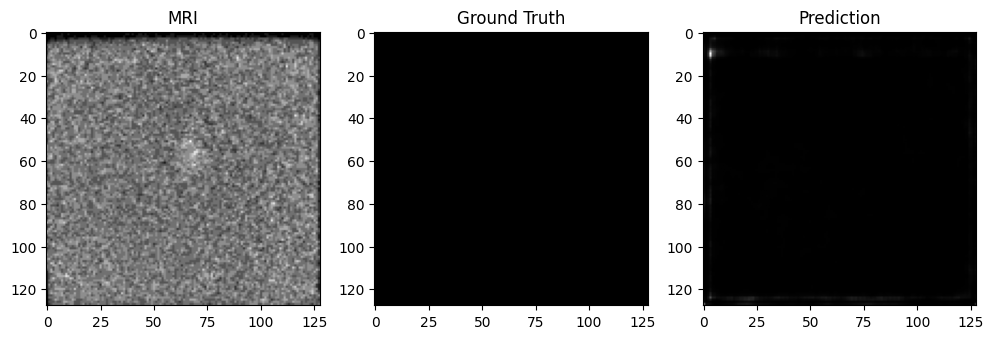

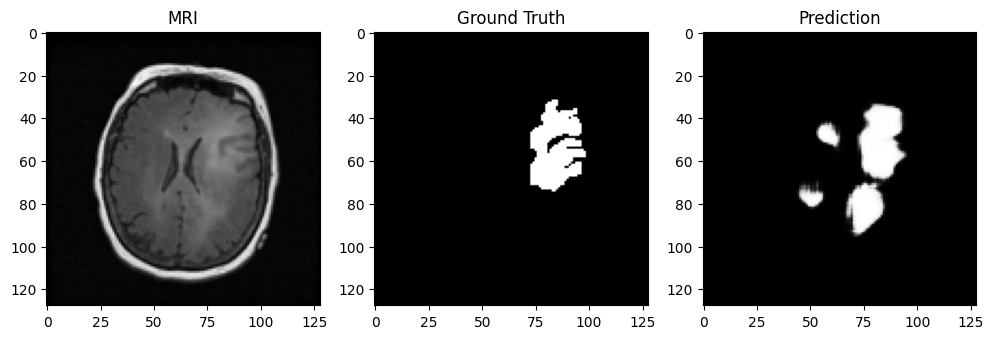

In [47]:
visualize(model, dataset)

# Compute the Dice coefficient for a batch of predicted and target masks:
# - Applies sigmoid and thresholds predictions at 0.5
# - Computes intersection and union over spatial dimensions (H, W)
# - Returns the mean Dice score across the batch

In [48]:
def dice_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = (2 * inter + smooth) / (union + smooth)
    return dice.mean()

# Evaluate the model on the validation set:
# - Sets model to evaluation mode
# - Disables gradient computation with torch.no_grad()
# - Computes Dice score for each batch in val_loader
# - Returns average Dice score across all validation batches

In [54]:
def validate(model):
    model.eval()
    dice_total = 0

    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)

            pred = model(img)
            dice_total += dice_score(pred, mask).item()

    return dice_total / len(val_loader)

# Define a fitness function for learning rate optimization:
# - Instantiates Attention U-Net and moves it to device
# - Uses Adam optimizer with the given learning rate and custom LossFn
# - Performs a few training steps on the training loader for speed
# - Evaluates the model on the validation set using validate()
# - Prints learning rate and corresponding validation Dice score
# - Returns the validation Dice as the fitness value

In [55]:
def fitness(lr):
    model = AttentionUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = LossFn()

    model.train()

    # quick training (few steps for speed)
    for i, (img, mask) in enumerate(train_loader):
        if i >= 3:
            break

        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 🔥 REAL METRIC
    val_dice = validate(model)

    print(f"LR={lr:.6f} | Val Dice={val_dice:.4f}")

    return val_dice

# Implement Differential Evolution (DE) to optimize the learning rate:
# - Initialize a population of candidate learning rates (log-uniform sampling between 1e-5 and 1e-3)
# - For a fixed number of iterations:
#     - Evaluate each candidate using the fitness() function (validation Dice)
#     - Select the best candidate in the current iteration
#     - Apply mutation and crossover to generate new population
# - Track and print the best learning rate and corresponding Dice score per iteration
# - Returns the final best learning rate after all iterations

In [56]:
import numpy as np
import random

def DE(iterations=4, pop_size=6):

    # search space (log scale)
    pop = [10**np.random.uniform(-5, -3) for _ in range(pop_size)]

    best_lr = None
    best_score = -1

    for it in range(iterations):

        print(f"\n===== DE ITERATION {it+1} =====")

        scores = []

        # evaluate population
        for lr in pop:
            score = fitness(lr)
            scores.append(score)

        # best selection
        best_idx = np.argmax(scores)

        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_lr = pop[best_idx]

        print(f"Best LR this iter: {pop[best_idx]:.6f} | Dice: {scores[best_idx]:.4f}")

        # mutation + crossover
        new_pop = []

        for i in range(pop_size):
            a, b, c = random.sample(pop, 3)

            mutant = a + 0.8 * (b - c)
            mutant = np.clip(mutant, 1e-6, 1e-2)

            new_pop.append(mutant)

        pop = new_pop

    print("\n====================")
    print(f"FINAL BEST LR: {best_lr:.6f}")
    print(f"FINAL BEST DICE: {best_score:.4f}")
    print("====================")

    return best_lr

# Run the Differential Evolution (DE) algorithm to find the optimal learning rate:
# - Calls DE() to search for the best LR
# - Stores the final best learning rate in best_lr

In [57]:
best_lr = DE()


===== DE ITERATION 1 =====
LR=0.000295 | Val Dice=0.6869
LR=0.000462 | Val Dice=0.6869
LR=0.000039 | Val Dice=0.0212
LR=0.000029 | Val Dice=0.6869
LR=0.000067 | Val Dice=0.0212
LR=0.000018 | Val Dice=0.0212
Best LR this iter: 0.000295 | Dice: 0.6869

===== DE ITERATION 2 =====
LR=0.000280 | Val Dice=0.0212
LR=0.000001 | Val Dice=0.0212
LR=0.000241 | Val Dice=0.0063
LR=0.000001 | Val Dice=0.0212
LR=0.000365 | Val Dice=0.0079
LR=0.000001 | Val Dice=0.6869
Best LR this iter: 0.000001 | Dice: 0.6869

===== DE ITERATION 3 =====
LR=0.000280 | Val Dice=0.6869
LR=0.000100 | Val Dice=0.6869
LR=0.000069 | Val Dice=0.0212
LR=0.000588 | Val Dice=0.0000
LR=0.000001 | Val Dice=0.0355
LR=0.000365 | Val Dice=0.6869
Best LR this iter: 0.000280 | Dice: 0.6869

===== DE ITERATION 4 =====
LR=0.000337 | Val Dice=0.0013
LR=0.000419 | Val Dice=0.0025
LR=0.000533 | Val Dice=0.6869
LR=0.000642 | Val Dice=0.0038
LR=0.000213 | Val Dice=0.0212
LR=0.000359 | Val Dice=0.6869
Best LR this iter: 0.000533 | Dice: 0.6

# Import essential libraries for dataset handling, model building, and visualization:
# - os, numpy, PIL for file and image operations
# - torch, torch.nn, torch.nn.functional for defining and training neural networks
# - Dataset, DataLoader, random_split for dataset management and batching
# - matplotlib.pyplot for plotting images and masks

In [63]:
import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Define a PyTorch Dataset for LGG MRI images and masks:
# - Collects valid image-mask pairs from subdirectories of root_dir
# - Resizes images and masks to img_size x img_size
# - Normalizes image pixels to [0,1] and converts masks to binary
# - Adds a channel dimension to tensors using unsqueeze
# - __getitem__ returns a tuple: (image_tensor, mask_tensor)

In [64]:
class LGGDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.samples = []
        self.img_size = img_size

        for patient in os.listdir(root_dir):
            p_path = os.path.join(root_dir, patient)

            if not os.path.isdir(p_path):
                continue

            for f in os.listdir(p_path):
                if f.endswith(".tif") and "_mask" not in f:
                    img_path = os.path.join(p_path, f)
                    mask_path = img_path.replace(".tif", "_mask.tif")

                    if os.path.exists(mask_path):
                        self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        img = np.array(img, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        # normalize
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)

        # binary mask
        mask = (mask > 0).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask

# Define a standard U-Net model for image segmentation:
# - ConvBlock: two Conv2d + ReLU layers for feature extraction
# - Encoder: two ConvBlocks with MaxPool downsampling
# - Bottleneck: ConvBlock at the bridge between encoder and decoder
# - Decoder: two upsampling layers using ConvTranspose2d and concatenation with encoder features
# - Output: 1-channel segmentation mask
# - forward(): passes input through encoder, bottleneck, and decoder with skip connections

In [65]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class AttentionUNet(nn.Module):
    def __init__(self, base=64):
        super().__init__()

        self.enc1 = ConvBlock(1, base)
        self.enc2 = ConvBlock(base, base*2)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base*2, base*4)

        self.up1 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.dec1 = ConvBlock(base*4, base*2)

        self.up2 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.dec2 = ConvBlock(base*2, base)

        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        u1 = self.up1(b)
        d1 = self.dec1(torch.cat([u1, e2], dim=1))

        u2 = self.up2(d1)
        d2 = self.dec2(torch.cat([u2, e1], dim=1))

        return self.out(d2)

# Define a custom loss function combining BCE and Focal Tversky Loss:
# - BCEWithLogitsLoss handles pixel-wise binary classification
# - Tversky index balances false positives (alpha) and false negatives (beta)
# - Focal term (gamma) emphasizes hard-to-segment pixels
# - forward() returns weighted sum: 0.5 * BCE + 0.5 * Focal Tversky

In [66]:
class LossFn(nn.Module):
    def __init__(self, a=0.7, b=0.3, g=0.75):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.a = a
        self.b = b
        self.g = g

    def forward(self, pred, true):
        bce = self.bce(pred, true)
        pred = torch.sigmoid(pred)

        tp = (pred * true).sum()
        fp = ((1 - true) * pred).sum()
        fn = (true * (1 - pred)).sum()

        tversky = (tp + 1e-6) / (tp + self.a*fp + self.b*fn + 1e-6)
        focal = (1 - tversky) ** self.g

        return 0.5 * bce + 0.5 * focal

# Define a custom loss function combining BCE and Focal Tversky Loss:
# - BCEWithLogitsLoss handles pixel-wise binary classification
# - Tversky index balances false positives (alpha) and false negatives (beta)
# - Focal term (gamma) emphasizes hard-to-segment pixels
# - forward() returns weighted sum: 0.5 * BCE + 0.5 * Focal Tversky

In [67]:
def dice(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    return (2 * inter + 1e-6) / (pred.sum() + target.sum() + 1e-6)


def iou(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter

    return (inter + 1e-6) / (union + 1e-6)

# Prepare the LGGDataset and DataLoaders:
# - root_dir: path to the dataset
# - img_size: resize images to 128×128
# - Split dataset into training (80%) and validation (20%) sets
# - Create DataLoaders with batch size 8; shuffle training data but not validation

In [69]:
# 🔥 CHANGE THIS ONLY
root_dir = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

dataset = LGGDataset(root_dir, img_size=128)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

# Train and evaluate the Attention U-Net model over multiple epochs:
# - Sets model and data on GPU if available
# - Uses Adam optimizer with a learning rate of 1e-4 and custom LossFn (BCE + Focal Tversky)
# - Computes and accumulates training loss and Dice score for each batch
# - After each epoch, evaluates validation Dice and IoU without gradient computation
# - Prints average training loss, training Dice, validation Dice, and validation IoU per epoch

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)
loss_fn = LossFn()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 100

for epoch in range(epochs):

    model.train()
    train_loss, train_dice = 0, 0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice(pred, mask).item()

    # -------- VALIDATION --------
    model.eval()
    val_dice, val_iou = 0, 0

    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)

            pred = model(img)

            val_dice += dice(pred, mask).item()
            val_iou += iou(pred, mask).item()

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Dice: {train_dice/len(train_loader):.4f} | "
        f"Val Dice: {val_dice/len(val_loader):.4f} | "
        f"Val IoU: {val_iou/len(val_loader):.4f}"
    )

Epoch 1 | Loss: 0.5109 | Train Dice: 0.0515 | Val Dice: 0.2042 | Val IoU: 0.1273
Epoch 2 | Loss: 0.4610 | Train Dice: 0.2211 | Val Dice: 0.2902 | Val IoU: 0.1900
Epoch 3 | Loss: 0.4413 | Train Dice: 0.2579 | Val Dice: 0.2755 | Val IoU: 0.1816
Epoch 4 | Loss: 0.4217 | Train Dice: 0.2885 | Val Dice: 0.3025 | Val IoU: 0.1986
Epoch 5 | Loss: 0.3882 | Train Dice: 0.3445 | Val Dice: 0.3565 | Val IoU: 0.2339
Epoch 6 | Loss: 0.3621 | Train Dice: 0.3951 | Val Dice: 0.4114 | Val IoU: 0.2854
Epoch 7 | Loss: 0.3446 | Train Dice: 0.4257 | Val Dice: 0.4457 | Val IoU: 0.3103
Epoch 8 | Loss: 0.3291 | Train Dice: 0.4539 | Val Dice: 0.4484 | Val IoU: 0.3123
Epoch 9 | Loss: 0.3178 | Train Dice: 0.4761 | Val Dice: 0.4754 | Val IoU: 0.3424
Epoch 10 | Loss: 0.3040 | Train Dice: 0.5070 | Val Dice: 0.4965 | Val IoU: 0.3644
Epoch 11 | Loss: 0.2979 | Train Dice: 0.5148 | Val Dice: 0.5261 | Val IoU: 0.3905
Epoch 12 | Loss: 0.2850 | Train Dice: 0.5389 | Val Dice: 0.5216 | Val IoU: 0.3867
Epoch 13 | Loss: 0.2768 |

# Visualize model predictions on sample images from the dataset:
# - Sets the model to evaluation mode (model.eval())
# - Applies sigmoid to model outputs to convert logits to probabilities
# - Loops over n samples (default 3)
# - Displays side-by-side:
#     1. Original MRI image
#     2. Ground truth (GT) mask
#     3. Model predicted mask
# - Uses matplotlib.pyplot for visualization

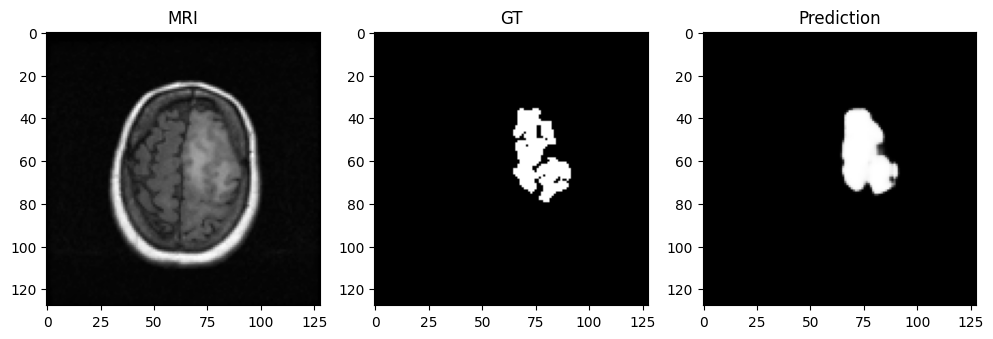

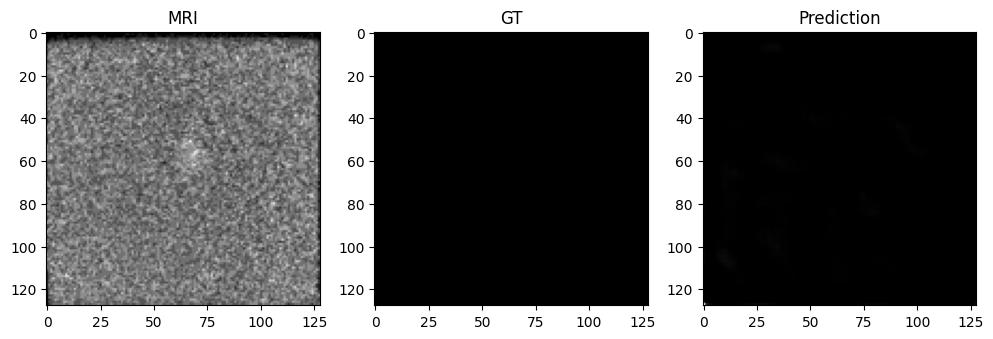

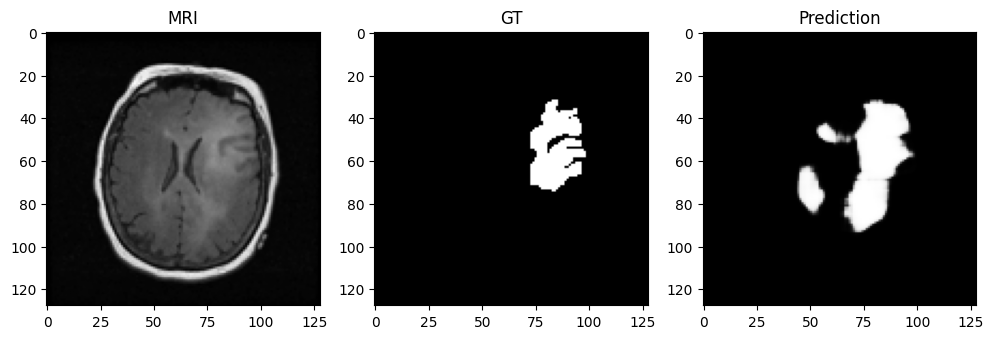

In [84]:
def visualize(model, dataset, n=3):
    model.eval()

    for i in range(n):
        img, mask = dataset[i]
        img_in = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(img_in)).cpu().squeeze().numpy()

        img = img.squeeze().numpy()
        mask = mask.squeeze().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("MRI")
        plt.imshow(img, cmap='gray')

        plt.subplot(1,3,2)
        plt.title("GT")
        plt.imshow(mask, cmap='gray')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap='gray')

        plt.show()

visualize(model, dataset)

# Import libraries and set up environment:
# - os, numpy, random, PIL for file and image operations
# - torch and torch.nn for defining and training neural networks
# - Dataset, DataLoader, random_split for dataset handling
# - matplotlib.pyplot for visualization
# - device: use GPU if available, otherwise CPU
# - root_dir: path to LGG MRI dataset
# - img_size: resize images to 128×128

In [94]:
import os
import numpy as np
import random
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root_dir = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"
img_size = 128

# Define a PyTorch Dataset class for LGG MRI images and masks:
# - Collects all valid image-mask pairs from subdirectories of root_dir
# - Resizes images and masks to img_size x img_size
# - Normalizes images to [0,1] and converts masks to binary
# - Adds a channel dimension using unsqueeze
# - __getitem__ returns a tuple: (image_tensor, mask_tensor)

In [95]:
class LGGDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for p in os.listdir(root_dir):
            pth = os.path.join(root_dir, p)
            if not os.path.isdir(pth):
                continue

            for f in os.listdir(pth):
                if f.endswith(".tif") and "_mask" not in f:
                    img = os.path.join(pth, f)
                    mask = img.replace(".tif", "_mask.tif")

                    if os.path.exists(mask):
                        self.samples.append((img, mask))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        img_path, mask_path = self.samples[i]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((img_size, img_size))
        mask = mask.resize((img_size, img_size))

        img = np.array(img, np.float32)
        mask = np.array(mask, np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        mask = (mask > 0).astype(np.float32)

        return torch.tensor(img).unsqueeze(0), torch.tensor(mask).unsqueeze(0)

# Define a standard Attention U-Net model for segmentation:
# - ConvBlock: two Conv2d + ReLU layers for feature extraction
# - Encoder: two ConvBlocks with MaxPool downsampling
# - Bottleneck: ConvBlock connecting encoder and decoder
# - Decoder: two upsampling layers using ConvTranspose2d and concatenation with encoder features
# - Output: 1-channel segmentation mask
# - forward(): passes input through encoder, bottleneck, and decoder with skip connections

In [96]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class AttentionUNet(nn.Module):
    def __init__(self, base=64):
        super().__init__()

        self.e1 = ConvBlock(1, base)
        self.e2 = ConvBlock(base, base*2)
        self.pool = nn.MaxPool2d(2)

        self.b = ConvBlock(base*2, base*4)

        self.up1 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.d1 = ConvBlock(base*4, base*2)

        self.up2 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.d2 = ConvBlock(base*2, base)

        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))

        b = self.b(self.pool(e2))

        u1 = self.up1(b)
        d1 = self.d1(torch.cat([u1, e2], dim=1))

        u2 = self.up2(d1)
        d2 = self.d2(torch.cat([u2, e1], dim=1))

        return self.out(d2)

# Define a custom loss function combining BCE and Focal Tversky:
# - BCEWithLogitsLoss handles pixel-wise binary classification
# - Tversky index balances false positives (alpha) and false negatives (beta)
# - Focal term (gamma) emphasizes hard-to-segment pixels
# - forward() returns weighted sum: 0.5 * BCE + 0.5 * Focal Tversky

In [97]:
class LossFn(nn.Module):
    def __init__(self, a=0.7, b=0.3, gamma=0.75):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.a = a
        self.b = b
        self.gamma = gamma

    def forward(self, pred, gt):

        bce = self.bce(pred, gt)
        pred = torch.sigmoid(pred)

        tp = (pred * gt).sum()
        fp = ((1-gt) * pred).sum()
        fn = (gt * (1-pred)).sum()

        tversky = (tp + 1e-6) / (tp + self.a*fp + self.b*fn + 1e-6)
        focal = (1 - tversky) ** self.gamma

        return 0.5 * bce + 0.5 * focal

# Define evaluation metrics for segmentation:
# - dice(): computes Dice coefficient for predicted vs target masks
# - iou(): computes Intersection over Union (IoU) for predicted vs target masks
# - Both apply sigmoid and threshold predictions at 0.5 before calculation

In [98]:
def dice(pred, gt):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    return (2*(pred*gt).sum() + 1e-6) / (pred.sum()+gt.sum()+1e-6)


def iou(pred, gt):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    inter = (pred*gt).sum()
    union = pred.sum()+gt.sum()-inter

    return (inter+1e-6)/(union+1e-6)

# Prepare LGGDataset and DataLoaders:
# - root_dir: path to dataset
# - Split dataset into training (80%) and validation (20%) sets
# - Create DataLoaders with batch size 8; shuffle training data but not validation

In [99]:
dataset = LGGDataset(root_dir)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

# Evaluate the model on the validation set:
# - Sets model to evaluation mode (model.eval())
# - Disables gradient computation with torch.no_grad()
# - Computes Dice score for each batch in val_loader
# - Returns the average Dice score across all validat

In [100]:
def validate(model):
    model.eval()
    d = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            d += dice(model(x), y).item()

    return d / len(val_loader)

# Implement Differential Evolution (DE) to optimize learning rate and base channels:
# - Initialize a population of candidate (learning rate, base channels) pairs
# - For a fixed number of iterations:
#     - Evaluate each candidate using fitness() (returns validation Dice)
#     - Track the best performing candidate
#     - Apply mutation and crossover to generate new population
# - Clips learning rate to [1e-6, 1e-2] and base channels to [32, 96]
# - Prints iteration-wise performance and returns the best (LR, base) pair

In [102]:
def DE():

    pop = [(10**random.uniform(-5,-3), random.choice([32,64,96])) for _ in range(6)]

    best = None
    best_score = -1

    for it in range(4):

        print("\nITER", it+1)

        scores = []

        for lr, base in pop:
            s = fitness(lr, base)
            scores.append(s)

            print(f"LR={lr:.6f}, BASE={base}, DICE={s:.4f}")

        idx = np.argmax(scores)

        if scores[idx] > best_score:
            best_score = scores[idx]
            best = pop[idx]

        new_pop = []

        for _ in pop:
            a,b,c = random.sample(pop,3)

            lr = np.clip(a[0] + 0.8*(b[0]-c[0]), 1e-6, 1e-2)
            base = int(np.clip(a[1] + random.choice([-16,16]), 32, 96))

            new_pop.append((lr, base))

        pop = new_pop

    print("\nFINAL BEST:", best, "DICE:", best_score)
    return best

# Train the Attention U-Net model:
# - Moves model and data to GPU if available
# - Uses Adam optimizer with learning rate 1e-4
# - Computes loss using custom LossFn (BCE + Focal Tversky)
# - Accumulates training loss over all batches
# - Evaluates model on validation set using validate() after each epoch
# - Prints average training loss and validation Dice score per epoch

In [105]:
model = AttentionUNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(100):

    model.train()
    loss_sum = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        loss = LossFn()(model(x), y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_sum += loss.item()

    val_dice = validate(model)

    print(f"Epoch {epoch+1} | Loss {loss_sum/len(train_loader):.4f} | Val Dice {val_dice:.4f}")

Epoch 1 | Loss 0.5145 | Val Dice 0.1788
Epoch 2 | Loss 0.4659 | Val Dice 0.2224
Epoch 3 | Loss 0.4412 | Val Dice 0.2765
Epoch 4 | Loss 0.4160 | Val Dice 0.3081
Epoch 5 | Loss 0.3979 | Val Dice 0.3077
Epoch 6 | Loss 0.3803 | Val Dice 0.3556
Epoch 7 | Loss 0.3533 | Val Dice 0.4495
Epoch 8 | Loss 0.3488 | Val Dice 0.3830
Epoch 9 | Loss 0.3333 | Val Dice 0.4527
Epoch 10 | Loss 0.3216 | Val Dice 0.4511
Epoch 11 | Loss 0.3071 | Val Dice 0.5128
Epoch 12 | Loss 0.2997 | Val Dice 0.5192
Epoch 13 | Loss 0.2969 | Val Dice 0.5289
Epoch 14 | Loss 0.2958 | Val Dice 0.5286
Epoch 15 | Loss 0.2746 | Val Dice 0.5223
Epoch 16 | Loss 0.2780 | Val Dice 0.5489
Epoch 17 | Loss 0.2731 | Val Dice 0.5156
Epoch 18 | Loss 0.2705 | Val Dice 0.5576
Epoch 19 | Loss 0.2668 | Val Dice 0.5215
Epoch 20 | Loss 0.2611 | Val Dice 0.5460
Epoch 21 | Loss 0.2568 | Val Dice 0.5293
Epoch 22 | Loss 0.2449 | Val Dice 0.5608
Epoch 23 | Loss 0.2528 | Val Dice 0.5433
Epoch 24 | Loss 0.2489 | Val Dice 0.5847
Epoch 25 | Loss 0.2263 | 

# Visualize model prediction for a single sample:
# - Sets model to evaluation mode
# - Selects the first sample from the dataset
# - Applies sigmoid to model output to get probabilities
# - Plots side-by-side:
#     1. Original MRI image
#     2. Ground truth (GT) mask
#     3. Model predicted mask
# - Uses matplotlib for visualization

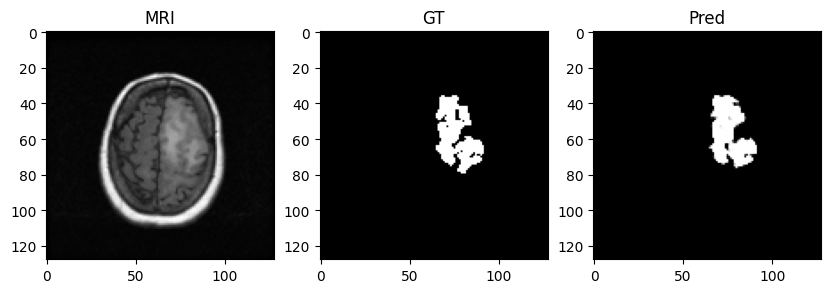

In [106]:
def show(model):
    model.eval()

    x,y = dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        p = torch.sigmoid(model(x)).cpu().squeeze()

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(x.cpu().squeeze(), cmap='gray')
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(y.squeeze(), cmap='gray')
    plt.title("GT")

    plt.subplot(1,3,3)
    plt.imshow(p, cmap='gray')
    plt.title("Pred")

    plt.show()


show(model)

# Train Attention U-Net on LGG MRI dataset:
# - Dataset: LGGDataset (resized to 128x128)
# - Split: 80% train, 20% validation
# - Loss: BCE + Focal Tversky
# - Optimizer: Adam, lr=1e-4
# - Metrics: Dice coefficient and IoU
# - Training: 100 epochs, accumulates batch loss, evaluates val Dice/IoU each epoch
# - Prints epoch-wise training loss and validation scores

In [1]:
import os
import numpy as np
import random
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms.functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# CONFIG
# =========================
root_dir = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"
img_size = 128
batch_size = 8
epochs = 100

# =========================
# DATASET
# =========================
class LGGDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for p in os.listdir(root_dir):
            pth = os.path.join(root_dir, p)
            if not os.path.isdir(pth):
                continue

            for f in os.listdir(pth):
                if f.endswith(".tif") and "_mask" not in f:
                    img = os.path.join(pth, f)
                    mask = img.replace(".tif", "_mask.tif")

                    if os.path.exists(mask):
                        self.samples.append((img, mask))

    def __len__(self):
        return len(self.samples)

    def augment(self, img, mask):
        if random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        if random.random() > 0.5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)

        angle = random.uniform(-15, 15)
        img = TF.rotate(img, angle)
        mask = TF.rotate(mask, angle)

        return img, mask

    def __getitem__(self, i):
        img_path, mask_path = self.samples[i]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((img_size, img_size))
        mask = mask.resize((img_size, img_size))

        img = np.array(img, np.float32)
        mask = np.array(mask, np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        mask = (mask > 0).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)

        img, mask = self.augment(img, mask)

        return img, mask


# =========================
# CBAM
# =========================
class CBAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(),
            nn.Linear(channels // r, channels)
        )

        self.spatial = nn.Conv2d(2, 1, 7, padding=3)

    def forward(self, x):
        b, c, h, w = x.size()

        # Channel attention
        avg = torch.mean(x, dim=(2, 3))

        # ❌ FIX: max pooling spatial correctly
        max_ = torch.amax(x, dim=(2, 3))

        attn = self.mlp(avg) + self.mlp(max_)
        attn = torch.sigmoid(attn).view(b, c, 1, 1)
        x = x * attn

        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out = torch.amax(x, dim=1, keepdim=True)

        spatial = torch.cat([avg_out, max_out], dim=1)
        spatial = torch.sigmoid(self.spatial(spatial))

        return x * spatial


# =========================
# CONV BLOCK
# =========================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


# =========================
# Q1 ATTENTION U-NET
# =========================
class Q1_UNet(nn.Module):
    def __init__(self, base=64):
        super().__init__()

        self.e1 = ConvBlock(1, base)
        self.e2 = ConvBlock(base, base*2)
        self.e3 = ConvBlock(base*2, base*4)

        self.pool = nn.MaxPool2d(2)

        self.cbam1 = CBAM(base*2)
        self.cbam2 = CBAM(base)

        self.b = ConvBlock(base*4, base*8)

        self.up1 = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.d1 = ConvBlock(base*8, base*4)

        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.d2 = ConvBlock(base*4, base*2)

        self.up3 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.d3 = ConvBlock(base*2, base)

        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.cbam1(self.e2(self.pool(e1)))
        e3 = self.e3(self.pool(e2))

        b = self.b(self.pool(e3))

        u1 = self.up1(b)
        d1 = self.d1(torch.cat([u1, e3], dim=1))

        u2 = self.up2(d1)
        d2 = self.d2(torch.cat([u2, e2], dim=1))

        u3 = self.up3(d2)
        d3 = self.cbam2(self.d3(torch.cat([u3, e1], dim=1)))

        return self.out(d3)


# =========================
# LOSS (Q1)
# =========================
class Q1Loss(nn.Module):
    def __init__(self, alpha=0.7, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, gt):

        bce = self.bce(pred, gt)
        pred = torch.sigmoid(pred)

        tp = (pred * gt).sum()
        fp = ((1-gt) * pred).sum()
        fn = (gt * (1-pred)).sum()

        dice = (2*tp + 1e-6) / (2*tp + fp + fn + 1e-6)

        focal_dice = (1 - dice) ** self.gamma

        return self.alpha * bce + (1 - self.alpha) * focal_dice


# =========================
# METRICS
# =========================
def dice_score(p, y):
    p = torch.sigmoid(p)
    p = (p > 0.5).float()
    return (2*(p*y).sum()+1e-6)/(p.sum()+y.sum()+1e-6)

def iou_score(p, y):
    p = torch.sigmoid(p)
    p = (p > 0.5).float()
    inter = (p*y).sum()
    union = p.sum()+y.sum()-inter
    return inter/(union+1e-6)


# =========================
# LOAD DATA
# =========================
dataset = LGGDataset(root_dir)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)


# =========================
# MODEL
# =========================
model = Q1_UNet().to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)

loss_fn = Q1Loss()

# =========================
# TRAINING
# =========================
best = 0
patience = 10
counter = 0

for epoch in range(epochs):

    model.train()
    loss_sum = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        loss = loss_fn(model(x), y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_sum += loss.item()

    # validation
    model.eval()
    dice_sum = 0
    iou_sum = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            pred = model(x)

            dice_sum += dice_score(pred, y).item()
            iou_sum += iou_score(pred, y).item()

    val_dice = dice_sum / len(val_loader)
    val_iou = iou_sum / len(val_loader)

    scheduler.step(val_dice)

    print(f"Epoch {epoch+1} | Loss {loss_sum/len(train_loader):.4f} | Dice {val_dice:.4f} | IoU {val_iou:.4f}")

    # early stopping
    if val_dice > best:
        best = val_dice
        counter = 0
        torch.save(model.state_dict(), "best_q1_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 1 | Loss 0.5228 | Dice 0.3733 | IoU 0.2538
Epoch 2 | Loss 0.2948 | Dice 0.5380 | IoU 0.3719
Epoch 3 | Loss 0.1840 | Dice 0.5081 | IoU 0.3604
Epoch 4 | Loss 0.1400 | Dice 0.2246 | IoU 0.1320
Epoch 5 | Loss 0.1329 | Dice 0.6353 | IoU 0.4770
Epoch 6 | Loss 0.1116 | Dice 0.6337 | IoU 0.4716
Epoch 7 | Loss 0.1014 | Dice 0.6197 | IoU 0.4564
Epoch 8 | Loss 0.0997 | Dice 0.6422 | IoU 0.4809
Epoch 9 | Loss 0.0940 | Dice 0.6131 | IoU 0.4781
Epoch 10 | Loss 0.0958 | Dice 0.7043 | IoU 0.5574
Epoch 11 | Loss 0.0811 | Dice 0.7025 | IoU 0.5618
Epoch 12 | Loss 0.0852 | Dice 0.7318 | IoU 0.5817
Epoch 13 | Loss 0.0845 | Dice 0.7115 | IoU 0.5415
Epoch 14 | Loss 0.0802 | Dice 0.6739 | IoU 0.5411
Epoch 15 | Loss 0.0760 | Dice 0.7423 | IoU 0.5994
Epoch 16 | Loss 0.0721 | Dice 0.7068 | IoU 0.5530
Epoch 17 | Loss 0.0730 | Dice 0.7470 | IoU 0.6028
Epoch 18 | Loss 0.0721 | Dice 0.7425 | IoU 0.6053
Epoch 19 | Loss 0.0684 | Dice 0.7052 | IoU 0.5704
Epoch 20 | Loss 0.0714 | Dice 0.7055 | IoU 0.5858
Epoch 21 